# Final Report: Visualisations & Reproducibility Documentation

This notebook generates paper-ready figures and documents experimental procedures  
for all models trained during this project.

---

In [17]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PATHS                                                  ║
# ╚══════════════════════════════════════════════════════════╝

# ParkCeleb data
CYMO_PC       = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_PC       = './cymo_parkceleb_per_recording_metadata.csv'
PC_ACOUSTIC   = './parkceleb_acoustic_features.csv'
FEAT_CSV      = './mrmr_top10_features.csv'

# KCL data
CYMO_KCL_RT   = '../KCL/ann.cymo_kcl_readtext_full.csv'
META_KCL_RT   = './cymo_kcl_readtext_full_metadata.csv'
CYMO_KCL_SD   = '../KCL/ann.cymo_kcl_dialogue_full.csv'
META_KCL_SD   = './cymo_kcl_dialogue_full_metadata.csv'
KCL_ACOUSTIC  = './kcl_audio_features.csv'

# Temporal metadata (ParkCeleb speakers_info with years_from_diagnosis)
TEMPORAL_CSV  = '../ParkCeleb/temporal_analysis/target_recordings.csv'  # from parkceleb_temporal.py

# Saved models (adjust to your actual filenames)
MODELS = {
    'LR (Base)':        './logreg_mrmr.joblib',
    'RF (Base)':        './rf_mrmr.joblib',
    'RF (mRMR, CV)':    './rf_mrmr_cv.joblib',
    'RF (multimodal)':  './rf_multimodal.joblib',
    'RF (best gen.)':   './rf_best_generalising.joblib',
    'SVM':              './svm_best.joblib',
    'Gradient Boosting': './gb_best.joblib',
}

In [18]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             roc_auc_score, confusion_matrix, roc_curve, auc)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10, 'axes.titleweight': 'bold',
                     'savefig.bbox': 'tight', 'savefig.facecolor': 'white'})

In [19]:
# ============================================================
# Load all available models
# ============================================================
loaded_models = {}
for name, path in MODELS.items():
    if os.path.isfile(path):
        loaded_models[name] = joblib.load(path)
        n_feat = len(loaded_models[name]['features'])
        print(f'  ✓ {name:<25s} ({n_feat} features)')
    else:
        print(f'  ✗ {name:<25s} — not found at {path}')

print(f'\nLoaded {len(loaded_models)} models')

  ✓ LR (Base)                 (25 features)
  ✓ RF (Base)                 (20 features)
  ✓ RF (mRMR, CV)             (24 features)
  ✓ RF (multimodal)           (27 features)
  ✓ RF (best gen.)            (24 features)
  ✓ SVM                       (48 features)
  ✓ Gradient Boosting         (48 features)

Loaded 7 models


In [20]:
# ============================================================
# Load ParkCeleb CYMO + acoustic data
# ============================================================
cymo = pd.read_csv(CYMO_PC)
meta = pd.read_csv(META_PC)
ling_features = pd.read_csv(FEAT_CSV)['feature'].tolist()

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]

pc_rec = cymo.merge(meta[[meta_tid, 'group', 'subject', 'video_id']].drop_duplicates(),
                    left_on=tid_col, right_on=meta_tid, how='inner')
pc_rec['label'] = (pc_rec['group'] == 'PD').astype(int)

for col in ling_features:
    pc_rec[col] = pd.to_numeric(pc_rec.get(col, 0), errors='coerce')
pc_rec[ling_features] = pc_rec[ling_features].fillna(pc_rec[ling_features].median())

# Merge acoustic
if os.path.isfile(PC_ACOUSTIC):
    ac = pd.read_csv(PC_ACOUSTIC)
    ac_cols = [c for c in ac.columns if c not in ('group','subject','video_id','filename')]
    ac_renamed = ac.rename(columns={c: f'ac_{c}' for c in ac_cols})
    ac_feat_cols = [f'ac_{c}' for c in ac_cols]
    pc_rec = pc_rec.merge(ac_renamed[['subject','video_id'] + ac_feat_cols],
                          on=['subject','video_id'], how='left')
    pc_rec[ac_feat_cols] = pc_rec[ac_feat_cols].fillna(0)

# Load temporal info
temporal = None
if os.path.isfile(TEMPORAL_CSV):
    temporal = pd.read_csv(TEMPORAL_CSV)
    print(f'Temporal data: {len(temporal)} recordings with years_from_diagnosis')

# Aggregate to subject level
all_feats_available = [c for c in pc_rec.columns if c.startswith('ac_')] + ling_features
pc_subj = pc_rec.groupby('subject').agg(
    {**{f: 'mean' for f in all_feats_available if f in pc_rec.columns}, 'label': 'first', 'group': 'first'}
).reset_index()

print(f'ParkCeleb: {len(pc_rec)} recordings, {len(pc_subj)} subjects')

Temporal data: 1603 recordings with years_from_diagnosis
ParkCeleb: 143818 recordings, 100 subjects


---
## 1 — Training Procedure Documentation

### 1.1 Random Forest with Cross-Validation

```
Dataset: ParkCeleb (100 subjects: 40 PD, 60 CN)
Features: 24 CYMO linguistic features selected via mRMR
Aggregation: Mean of each feature across all recordings per subject

Split:
  ├── 70 subjects → Training pool
  │     └── 5-fold StratifiedGroupKFold
  │           ├── Fold 1: ~56 train, ~14 validate
  │           ├── Fold 2: ~56 train, ~14 validate
  │           ├── Fold 3: ~56 train, ~14 validate
  │           ├── Fold 4: ~56 train, ~14 validate
  │           └── Fold 5: ~56 train, ~14 validate
  │           → Each subject validated exactly once
  │           → Grid search over hyperparameters
  │           → Best config selected by subject-level AUC
  │
  └── 30 subjects → Dedicated test set (never seen during training)
        → Final model retrained on all 70 training subjects
        → Evaluated once on these 30 subjects

Hyperparameters searched:
  n_estimators: [100, 200, 500]
  max_depth:    [3, 5, 10, None]
  min_samples_leaf: [3, 5]
  class_weight: 'balanced' (fixed)
```

### 1.2 SVM
```
Same 70/30 subject split
Features: subject-level mean + std (2× features)
20 random splits averaged for robust estimation

Hyperparameters searched:
  kernel: ['rbf', 'linear', 'poly']
  C:      [0.1, 0.5, 1.0, 5.0, 10.0]
  gamma:  ['scale', 'auto', 0.01, 0.1]
  class_weight: 'balanced'
```

### 1.3 Gradient Boosting
```
Same 70/30 subject split
Features: subject-level mean + std
20 random splits averaged

Hyperparameters searched:
  n_estimators:    [50, 100, 200, 300]
  max_depth:       [1, 2, 3]
  learning_rate:   [0.05, 0.1]
  min_samples_leaf:[3, 5, 10]
  subsample:       [0.7, 0.8, 1.0]
```

In [21]:
# ============================================================
# 2.  RF CV: training vs test accuracy (best params hardcoded)
# ============================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedGroupKFold

# Best parameters (found in previous experiments)
RF_PARAMS  = {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
SVM_PARAMS = {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'}
GB_PARAMS  = {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1,
              'min_samples_leaf': 3, 'subsample': 1.0}

# Use mRMR features
feats = ling_features
available_feats = [f for f in feats if f in pc_subj.columns]

# 70/30 split (seed=42)
np.random.seed(42)
cn_s = pc_subj[pc_subj['label']==0].sample(frac=1, random_state=42)
pd_s = pc_subj[pc_subj['label']==1].sample(frac=1, random_state=42)
cs, ps = int(len(cn_s)*0.7), int(len(pd_s)*0.7)
train_subj = pd.concat([cn_s.iloc[:cs], pd_s.iloc[:ps]])
test_subj = pd.concat([cn_s.iloc[cs:], pd_s.iloc[ps:]])

scaler = StandardScaler()
X_tr = scaler.fit_transform(train_subj[available_feats].fillna(0).values)
X_te = scaler.transform(test_subj[available_feats].fillna(0).values)
y_tr = train_subj['label'].values
y_te = test_subj['label'].values
groups = train_subj['subject'].values

# ---- RF: 5-fold CV then final model ----
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_tr, y_tr, groups)):
    rf = RandomForestClassifier(**RF_PARAMS, class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr[tr_idx], y_tr[tr_idx])
    
    train_acc = accuracy_score(y_tr[tr_idx], rf.predict(X_tr[tr_idx]))
    val_acc = accuracy_score(y_tr[va_idx], rf.predict(X_tr[va_idx]))
    val_prob = rf.predict_proba(X_tr[va_idx])[:, 1]
    val_auc = roc_auc_score(y_tr[va_idx], val_prob) if len(np.unique(y_tr[va_idx])) > 1 else 0.5
    
    fold_results.append({
        'fold': fold+1,
        'train_subj': len(set(groups[tr_idx])),
        'val_subj': len(set(groups[va_idx])),
        'train_acc': train_acc, 'val_acc': val_acc, 'val_auc': val_auc,
    })

final_rf = RandomForestClassifier(**RF_PARAMS, class_weight='balanced', random_state=42, n_jobs=-1)
final_rf.fit(X_tr, y_tr)
train_full_acc = accuracy_score(y_tr, final_rf.predict(X_tr))
test_acc = accuracy_score(y_te, final_rf.predict(X_te))
test_auc = roc_auc_score(y_te, final_rf.predict_proba(X_te)[:, 1])

fold_df = pd.DataFrame(fold_results)

# ---- Print RF results ----
print('RANDOM FOREST')
print('=' * 65)
print(f'Parameters: {RF_PARAMS}')
print(f'Training: {len(train_subj)} subjects  |  Test: {len(test_subj)} subjects')
print(f'\n{"Fold":<6s} {"Train Subj":>11s} {"Val Subj":>9s} {"Train Acc":>10s} {"Val Acc":>9s} {"Val AUC":>9s}')
print('─' * 58)
for _, r in fold_df.iterrows():
    print(f'{r["fold"]:<6.0f} {r["train_subj"]:>11.0f} {r["val_subj"]:>9.0f} '
          f'{r["train_acc"]:>10.3f} {r["val_acc"]:>9.3f} {r["val_auc"]:>9.3f}')
print('─' * 58)
print(f'{"Mean":<6s} {"":>11s} {"":>9s} '
      f'{fold_df["train_acc"].mean():>10.3f} {fold_df["val_acc"].mean():>9.3f} {fold_df["val_auc"].mean():>9.3f}')
print(f'\nFinal RF (all {len(train_subj)} training subjects):')
print(f'  Training accuracy : {train_full_acc:.3f}')
print(f'  Test accuracy     : {test_acc:.3f}')
print(f'  Test AUC          : {test_auc:.3f}')

# ---- SVM ----
svm = SVC(**SVM_PARAMS, class_weight='balanced', probability=True, random_state=42)
svm.fit(X_tr, y_tr)
svm_train_acc = accuracy_score(y_tr, svm.predict(X_tr))
svm_test_acc = accuracy_score(y_te, svm.predict(X_te))
svm_test_auc = roc_auc_score(y_te, svm.predict_proba(X_te)[:, 1])

print(f'\nSVM (kernel={SVM_PARAMS["kernel"]}, C={SVM_PARAMS["C"]})')
print(f'  Training accuracy : {svm_train_acc:.3f}')
print(f'  Test accuracy     : {svm_test_acc:.3f}')
print(f'  Test AUC          : {svm_test_auc:.3f}')

# ---- Gradient Boosting ----
gb = GradientBoostingClassifier(**GB_PARAMS, random_state=42)
gb.fit(X_tr, y_tr)
gb_train_acc = accuracy_score(y_tr, gb.predict(X_tr))
gb_test_acc = accuracy_score(y_te, gb.predict(X_te))
gb_test_auc = roc_auc_score(y_te, gb.predict_proba(X_te)[:, 1])

print(f'\nGRADIENT BOOSTING (n={GB_PARAMS["n_estimators"]}, d={GB_PARAMS["max_depth"]}, lr={GB_PARAMS["learning_rate"]})')
print(f'  Training accuracy : {gb_train_acc:.3f}')
print(f'  Test accuracy     : {gb_test_acc:.3f}')
print(f'  Test AUC          : {gb_test_auc:.3f}')

# ---- Combined summary ----
print(f'\n{"=" * 60}')
print(f'{"Model":<25s} {"Train Acc":>10s} {"Test Acc":>10s} {"Test AUC":>10s}')
print(f'{"─" * 60}')
print(f'{"RF (CV mean val)":<25s} {fold_df["train_acc"].mean():>10.3f} {fold_df["val_acc"].mean():>10.3f} {fold_df["val_auc"].mean():>10.3f}')
print(f'{"RF (final)":<25s} {train_full_acc:>10.3f} {test_acc:>10.3f} {test_auc:>10.3f}')
print(f'{"SVM (linear)":<25s} {svm_train_acc:>10.3f} {svm_test_acc:>10.3f} {svm_test_auc:>10.3f}')
print(f'{"Gradient Boosting":<25s} {gb_train_acc:>10.3f} {gb_test_acc:>10.3f} {gb_test_auc:>10.3f}')

RANDOM FOREST
Parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Training: 70 subjects  |  Test: 30 subjects

Fold    Train Subj  Val Subj  Train Acc   Val Acc   Val AUC
──────────────────────────────────────────────────────────
1               56        14      0.946     0.857     0.867
2               56        14      0.946     0.643     0.646
3               56        14      0.982     0.786     0.917
4               56        14      0.946     0.714     0.778
5               56        14      0.964     0.786     0.646
──────────────────────────────────────────────────────────
Mean                              0.957     0.757     0.771

Final RF (all 70 training subjects):
  Training accuracy : 0.943
  Test accuracy     : 0.867
  Test AUC          : 0.940

SVM (kernel=linear, C=0.1)
  Training accuracy : 0.871
  Test accuracy     : 0.900
  Test AUC          : 0.926

GRADIENT BOOSTING (n=50, d=2, lr=0.1)
  Training accuracy : 1.000
  Tes

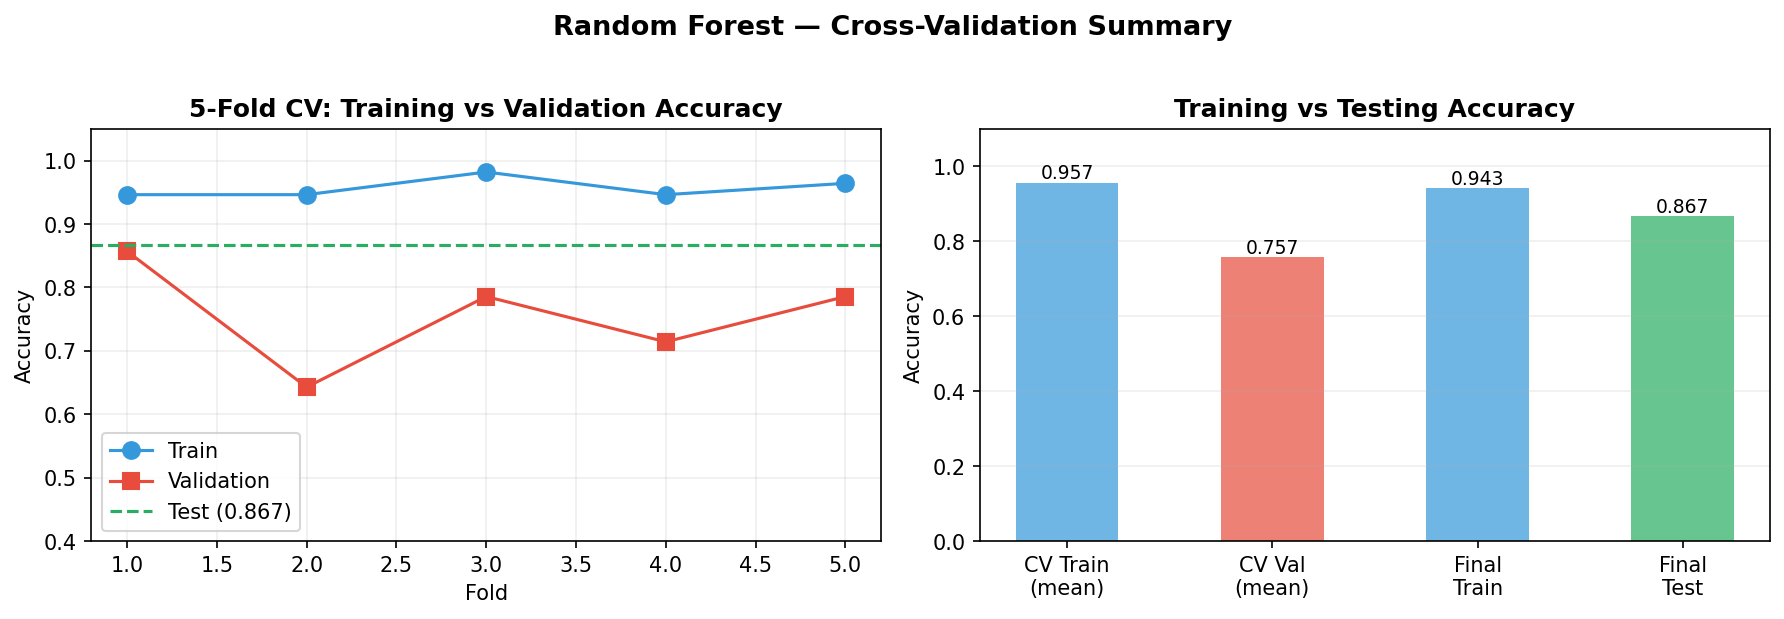

In [22]:
# ============================================================
# 2.1  CV training vs validation accuracy plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x = fold_df['fold']
ax.plot(x, fold_df['train_acc'], 'o-', color='#3498DB', label='Train', ms=8)
ax.plot(x, fold_df['val_acc'], 's-', color='#E74C3C', label='Validation', ms=8)
ax.axhline(test_acc, color='#27AE60', ls='--', lw=1.5, label=f'Test ({test_acc:.3f})')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
ax.set_title('5-Fold CV: Training vs Validation Accuracy')
ax.set_ylim(0.4, 1.05); ax.legend(); ax.grid(alpha=0.2)

ax = axes[1]
bars = ax.bar(['CV Train\n(mean)', 'CV Val\n(mean)', 'Final\nTrain', 'Final\nTest'],
              [fold_df['train_acc'].mean(), fold_df['val_acc'].mean(), train_full_acc, test_acc],
              color=['#3498DB', '#E74C3C', '#3498DB', '#27AE60'], alpha=0.7, width=0.5)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy'); ax.grid(axis='y', alpha=0.2)

plt.suptitle('Random Forest — Cross-Validation Summary', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('paper_cv_accuracy.png', dpi=200, bbox_inches='tight'); plt.show()

---
## 3 — Temporal Scatter: Prediction vs Years from Diagnosis

In [23]:
# ============================================================
# 3.  Temporal scatter plot — per-recording prediction vs time
# ============================================================

# We need per-recording predictions with years_from_diagnosis
# Use the best RF model on ALL ParkCeleb recordings

# Pick the best available model
model_name = next((n for n in ['RF (multimodal)', 'RF (best gen.)', 'RF (mRMR, CV)']
                   if n in loaded_models), None)

if model_name and temporal is not None:
    saved = loaded_models[model_name]
    model = saved['model']
    model_scaler = saved['scaler']
    model_feats = saved['features']
    
    print(f'Using model: {model_name} ({len(model_feats)} features)')
    
    # Prepare per-recording features
    # If model uses subject-level aggregated features, we still predict per-recording
    # using the recording's own feature values
    for col in model_feats:
        if col not in pc_rec.columns:
            pc_rec[col] = 0.0
    
    X_all = model_scaler.transform(pc_rec[model_feats].fillna(0).values)
    pc_rec['pred'] = model.predict(X_all)
    pc_rec['prob'] = model.predict_proba(X_all)[:, 1]
    pc_rec['correct'] = (pc_rec['pred'] == pc_rec['label']).astype(int)
    
    # Merge with temporal data to get years_from_diagnosis
    # Temporal CSV has columns like: group, subject, video_id, years_from_diagnosis
    # Use whichever column has the video ID
    if 'video_id' in temporal.columns:
        vid_col = 'video_id'
    elif 'video_folder' in temporal.columns:
        vid_col = 'video_folder'
    else:
        vid_col = None
    
    yrs_col = next((c for c in temporal.columns if 'years' in c.lower()), None)
    ba_col = next((c for c in temporal.columns if 'before_after' in c.lower()), None)
    
    if yrs_col:
        temporal[yrs_col] = pd.to_numeric(temporal[yrs_col], errors='coerce')
        # Merge
        merge_temp = temporal[['subject', vid_col, yrs_col]].drop_duplicates()
        if vid_col != 'video_id':
            # Remove duplicate columns in pc_rec
            pc_rec = pc_rec.loc[:, ~pc_rec.columns.duplicated()]
            merge_temp = merge_temp.rename(columns={vid_col: 'video_id'})
        pc_temporal = pc_rec.merge(merge_temp, on=['subject', 'video_id'], how='left')
        
        has_years = pc_temporal[yrs_col].notna()
        print(f'Recordings with temporal data: {has_years.sum()}/{len(pc_temporal)}')
        
        pc_plot = pc_temporal[has_years].copy()
    else:
        print('No years_from_diagnosis column found in temporal data')
        pc_plot = None
else:
    print('Model or temporal data not available.')
    print('  Set TEMPORAL_CSV to the target_recordings.csv from parkceleb_temporal.py')
    pc_plot = None

Using model: RF (multimodal) (27 features)
Recordings with temporal data: 48301/143941


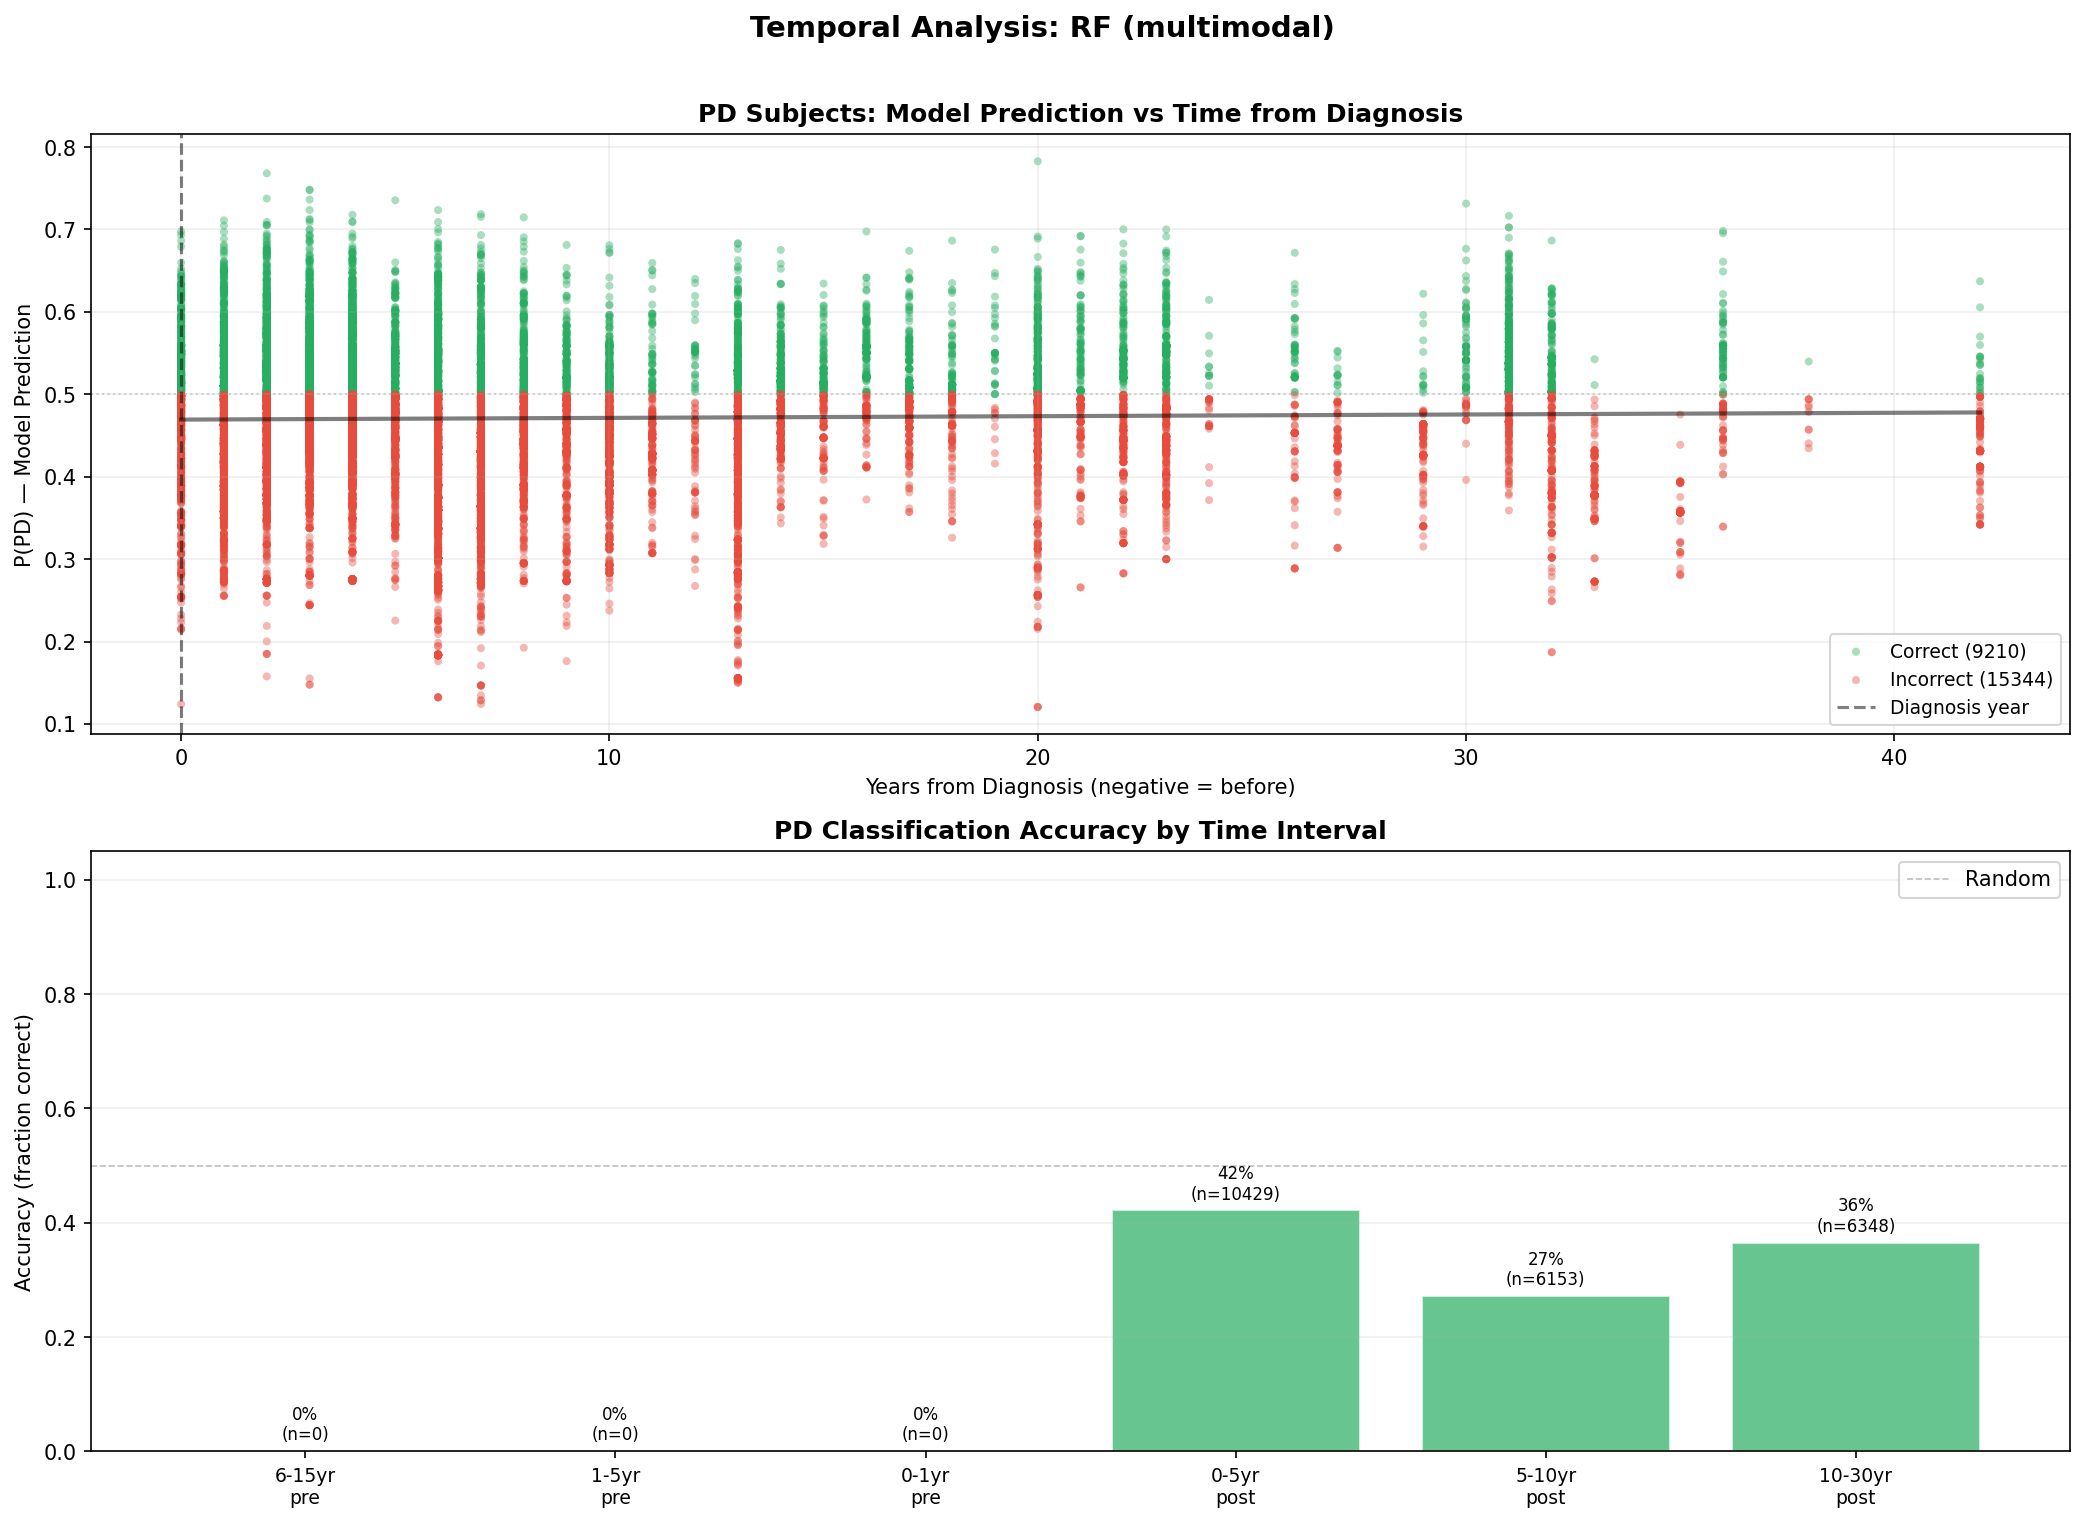

In [30]:
# ============================================================
# 3.1  Temporal scatter: years from diagnosis vs prediction
# ============================================================
if pc_plot is not None and yrs_col:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Panel 1: PD subjects only
    ax = axes[0]
    pd_plot = pc_plot[pc_plot['label'] == 1]
    correct = pd_plot[pd_plot['correct'] == 1]
    wrong = pd_plot[pd_plot['correct'] == 0]

    ax.scatter(correct[yrs_col], correct['prob'], s=15, alpha=0.4,
               c='#27AE60', label=f'Correct ({len(correct)})', edgecolors='none')
    ax.scatter(wrong[yrs_col], wrong['prob'], s=15, alpha=0.4,
               c='#E74C3C', label=f'Incorrect ({len(wrong)})', edgecolors='none')

    ax.axvline(0, color='black', ls='--', lw=1.5, alpha=0.5, label='Diagnosis year')
    ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.3)
    ax.set_xlabel('Years from Diagnosis (negative = before)')
    ax.set_ylabel('P(PD) — Model Prediction')
    ax.set_title('PD Subjects: Model Prediction vs Time from Diagnosis')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.2)

    # Add trend line
    if len(pd_plot) > 10:
        z = np.polyfit(pd_plot[yrs_col].values, pd_plot['prob'].values, 1)
        trend_x = np.linspace(pd_plot[yrs_col].min(), pd_plot[yrs_col].max(), 100)
        ax.plot(trend_x, np.polyval(z, trend_x), 'k-', lw=2, alpha=0.5, label='Trend')

    # Panel 2: Accuracy by time bin
    ax = axes[1]
    bins = [(-15, -5), (-5, -1), (-1, 0), (0, 5), (5, 10), (10, 30)]
    bin_labels = ['6-15yr\npre', '1-5yr\npre', '0-1yr\npre',
                  '0-5yr\npost', '5-10yr\npost', '10-30yr\npost']
    bin_accs = []
    bin_counts = []

    for lo, hi in bins:
        mask = (pd_plot[yrs_col] >= lo) & (pd_plot[yrs_col] < hi)
        subset = pd_plot[mask]
        if len(subset) > 0:
            bin_accs.append(subset['correct'].mean())
            bin_counts.append(len(subset))
        else:
            bin_accs.append(0)
            bin_counts.append(0)

    bar_colors = ['#F39C12' if lo < 0 else '#27AE60' for lo, hi in bins]
    bars = ax.bar(range(len(bins)), bin_accs, color=bar_colors, alpha=0.7, edgecolor='white')
    ax.set_xticks(range(len(bins)))
    ax.set_xticklabels(bin_labels, fontsize=9)
    ax.set_ylabel('Accuracy (fraction correct)')
    ax.set_title('PD Classification Accuracy by Time Interval')
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5, label='Random')
    ax.set_ylim(0, 1.05)

    for i, (bar, count) in enumerate(zip(bars, bin_counts)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{bar.get_height():.0%}\n(n={count})', ha='center', fontsize=8)
    ax.legend(); ax.grid(axis='y', alpha=0.2)

    plt.suptitle(f'Temporal Analysis: {model_name}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('paper_temporal_scatter.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('Skipping temporal plot (data not available)')

---
## 4 — All-Models Comparison Table & Figures

In [32]:
# ============================================================
# 4.  Evaluate every loaded model on ParkCeleb test + KCL
# ============================================================

# KCL data (load once)
kcl_dfs = []
for cp, mp in [(CYMO_KCL_RT, META_KCL_RT), (CYMO_KCL_SD, META_KCL_SD)]:
    if not os.path.isfile(cp): continue
    c = pd.read_csv(cp); m = pd.read_csv(mp)
    tc = 'TID' if 'TID' in c.columns else c.columns[0]
    mc = 'TID' if 'TID' in m.columns else m.columns[0]
    sc = next((x for x in m.columns if x in ('subject','subject_id')), None)
    merged = c.merge(m[[mc,'group',sc]].drop_duplicates(), left_on=tc, right_on=mc, how='inner')
    if sc != 'subject': merged = merged.rename(columns={sc: 'subject'})
    merged['group'] = merged['group'].replace({'HC': 'CN'})
    merged['label'] = (merged['group'] == 'PD').astype(int)
    kcl_dfs.append(merged)

#kcl_all = pd.concat(kcl_dfs, ignore_index=True) if kcl_dfs else None
kcl_all = pd.concat(kcl_dfs, ignore_index=True) if kcl_dfs else None
kcl_rt = kcl_dfs[0] if len(kcl_dfs) > 0 else None   # ReadText
kcl_sd = kcl_dfs[1] if len(kcl_dfs) > 1 else None   # Dialogue

# KCL acoustic
kcl_ac = None
if os.path.isfile(KCL_ACOUSTIC):
    kcl_ac = pd.read_csv(KCL_ACOUSTIC)
    kcl_ac['group'] = kcl_ac['group'].replace({'HC': 'CN'})
    if 'subject' not in kcl_ac.columns and 'filename' in kcl_ac.columns:
        kcl_ac['subject'] = kcl_ac['filename'].str.split('_').str[0]

# Evaluate each model
comparison = []

for name, saved in loaded_models.items():
    model = saved['model']
    model_sc = saved['scaler']
    model_feats = saved['features']
    
    # ParkCeleb test (70/30 split, seed=42)
    for col in model_feats:
        if col not in pc_subj.columns: pc_subj[col] = 0.0
    
    np.random.seed(42)
    cn_s = pc_subj[pc_subj['label']==0].sample(frac=1, random_state=42)
    pd_s = pc_subj[pc_subj['label']==1].sample(frac=1, random_state=42)
    cs, ps = int(len(cn_s)*0.7), int(len(pd_s)*0.7)
    test = pd.concat([cn_s.iloc[cs:], pd_s.iloc[ps:]])
    
    try:
        X_te = model_sc.transform(test[model_feats].fillna(0).values)
        y_te = test['label'].values
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        
        pc_result = {
            'pc_acc': accuracy_score(y_te, y_pred),
            'pc_f1': f1_score(y_te, y_pred, zero_division=0),
            'pc_auc': roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5,
            'pc_sens': recall_score(y_te, y_pred, zero_division=0),
            'pc_spec': recall_score(y_te, y_pred, pos_label=0, zero_division=0),
        }
    except Exception as e:
        pc_result = {'pc_acc': 0, 'pc_f1': 0, 'pc_auc': 0.5, 'pc_sens': 0, 'pc_spec': 0}
    
    # KCL cross-corpus
    kcl_result = {'kcl_rt_acc': '-', 'kcl_rt_auc': '-', 'kcl_sd_acc': '-', 'kcl_sd_auc': '-'}
    
    for kcl_data, prefix in [(kcl_rt, 'kcl_rt'), (kcl_sd, 'kcl_sd')]:
        if kcl_data is None: continue
        try:
            kcl_subj = kcl_data.groupby('subject').agg(
                {**{f: 'mean' for f in model_feats if f in kcl_data.columns}, 'label': 'first'}
            ).reset_index()
            for col in model_feats:
                if col not in kcl_subj.columns: kcl_subj[col] = 0.0
            X_kcl = model_sc.transform(kcl_subj[model_feats].fillna(0).values)
            y_kcl = kcl_subj['label'].values
            kcl_result[f'{prefix}_acc'] = accuracy_score(y_kcl, model.predict(X_kcl))
            kcl_result[f'{prefix}_auc'] = roc_auc_score(y_kcl, model.predict_proba(X_kcl)[:,1]) if len(np.unique(y_kcl))>1 else 0.5
        except Exception:
            pass
    
    comparison.append({'model': name, 'n_features': len(model_feats), **pc_result, **kcl_result})

comp_df = pd.DataFrame(comparison)

print('ALL MODELS — COMPARISON TABLE')
print('=' * 115)
print(f'{"Model":<25s} {"#Feat":>6s} {"PC Acc":>7s} {"PC AUC":>7s} {"PC Sens":>8s} {"PC Spec":>8s} {"KCL RT Acc":>10s} {"KCL RT AUC":>10s} {"KCL SD Acc":>10s} {"KCL SD AUC":>10s}')
print('─' * 115)
for _, r in comp_df.iterrows():
    def fmt(v): return f'{v:.3f}' if isinstance(v, float) else str(v)
    print(f'{r["model"]:<25s} {r["n_features"]:>6d} {r["pc_acc"]:>7.3f} {r["pc_auc"]:>7.3f} '
          f'{r["pc_sens"]:>8.3f} {r["pc_spec"]:>8.3f} {fmt(r["kcl_rt_acc"]):>10s} {fmt(r["kcl_rt_auc"]):>10s} '
          f'{fmt(r["kcl_sd_acc"]):>10s} {fmt(r["kcl_sd_auc"]):>10s}')

ALL MODELS — COMPARISON TABLE
Model                      #Feat  PC Acc  PC AUC  PC Sens  PC Spec KCL RT Acc KCL RT AUC KCL SD Acc KCL SD AUC
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
LR (Base)                     25   0.433   0.829    1.000    0.056      0.405      0.420      0.528      0.505
RF (Base)                     20   0.567   0.472    0.167    0.833      0.486      0.484      0.556      0.610
RF (mRMR, CV)                 24   0.767   0.789    0.917    0.667      0.568      0.576      0.667      0.692
RF (multimodal)               27   0.933   1.000    1.000    0.889      0.405      0.524      0.556      0.552
RF (best gen.)                24   0.967   1.000    1.000    0.944      0.541      0.449      0.556      0.578
SVM                           48   0.600   0.500    0.000    1.000      0.568      0.500      0.583      0.500
Gradient Boosting             48   0.600   0.500    0.000    1.000      0.568

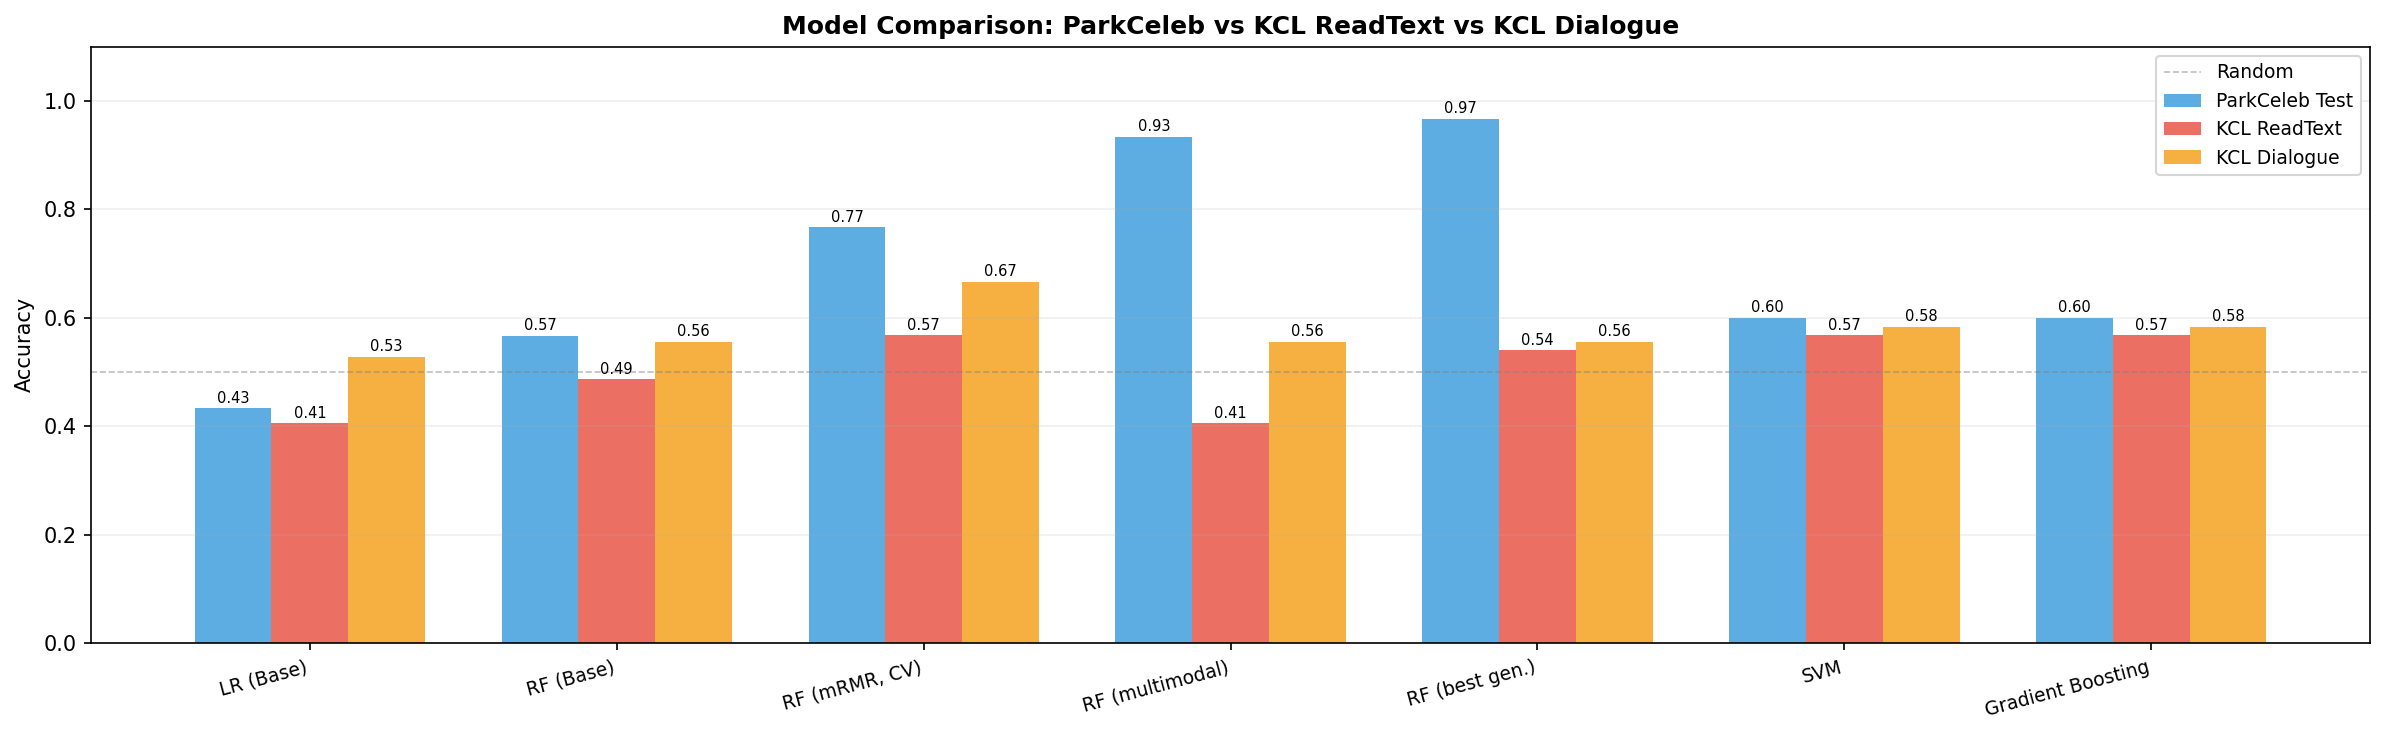

In [33]:
# ============================================================
# 4.1  Paper-ready comparison bar chart
# ============================================================
fig, ax = plt.subplots(figsize=(16, 5))

x = np.arange(len(comp_df))
w = 0.25

bars1 = ax.bar(x - w, comp_df['pc_acc'], w, label='ParkCeleb Test', color='#3498DB', alpha=0.8)

kcl_rt_vals = comp_df['kcl_rt_acc'].apply(lambda v: float(v) if isinstance(v, float) else 0)
kcl_sd_vals = comp_df['kcl_sd_acc'].apply(lambda v: float(v) if isinstance(v, float) else 0)
bars2 = ax.bar(x, kcl_rt_vals, w, label='KCL ReadText', color='#E74C3C', alpha=0.8)
bars3 = ax.bar(x + w, kcl_sd_vals, w, label='KCL Dialogue', color='#F39C12', alpha=0.8)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        if bar.get_height() > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{bar.get_height():.2f}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(comp_df['model'], fontsize=9, rotation=15, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: ParkCeleb vs KCL ReadText vs KCL Dialogue')
ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5, label='Random')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)

plt.tight_layout(); plt.savefig('paper_model_comparison.png', dpi=200, bbox_inches='tight'); plt.show()

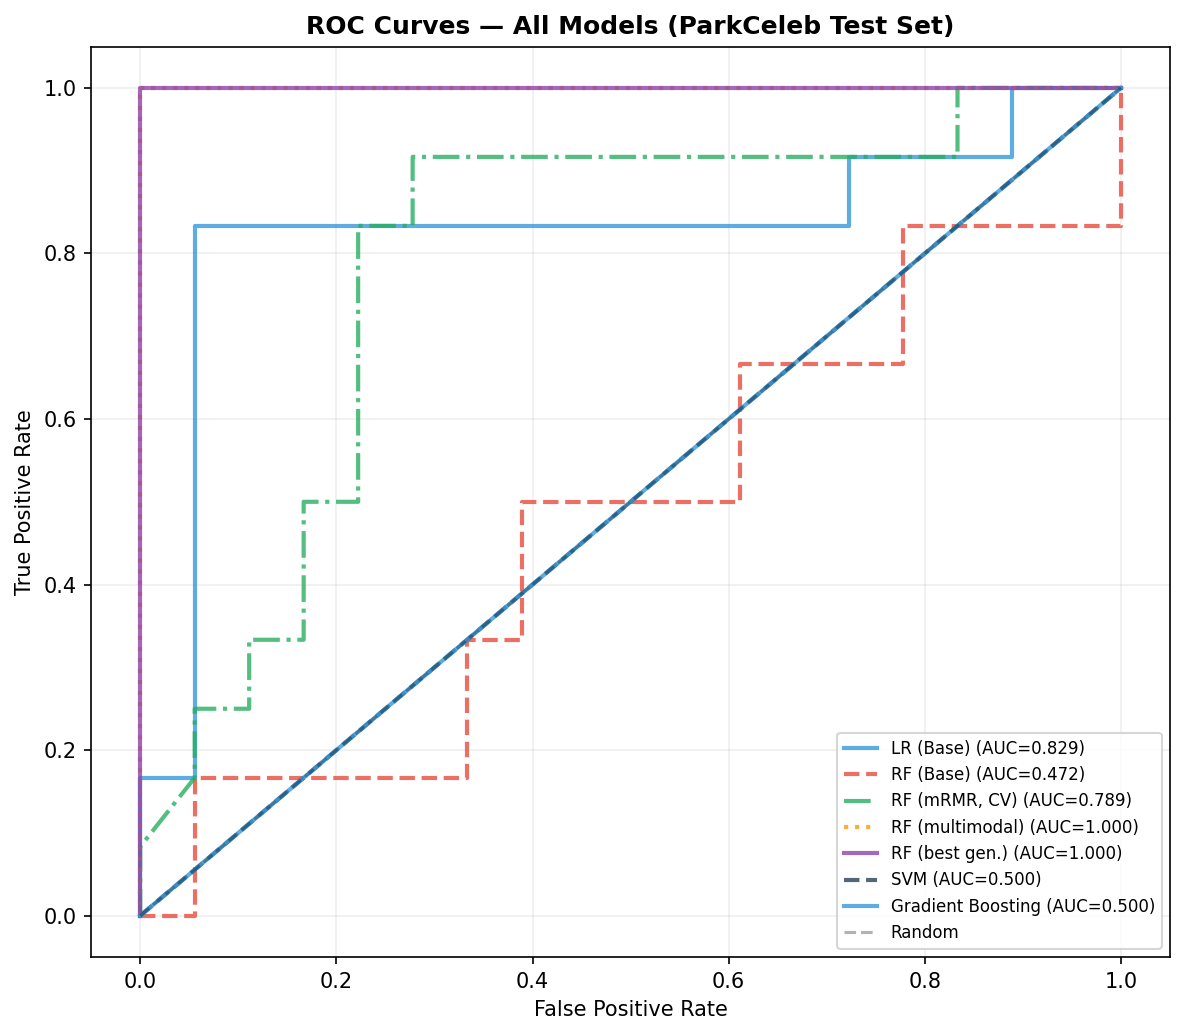

In [27]:
# ============================================================
# 4.2  ROC curves for all models (ParkCeleb test set)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#3498DB', '#E74C3C', '#27AE60', '#F39C12', '#8E44AD', '#2C3E50']
styles = ['-', '--', '-.', ':', '-', '--']

for i, (name, saved) in enumerate(loaded_models.items()):
    try:
        model = saved['model']; model_sc = saved['scaler']; mf = saved['features']
        for col in mf:
            if col not in test.columns: test[col] = 0.0
        X = model_sc.transform(test[mf].fillna(0).values)
        y_prob = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(test['label'].values, y_prob)
        auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i % len(colors)], ls=styles[i % len(styles)],
                lw=2, alpha=0.8, label=f'{name} (AUC={auc_val:.3f})')
    except Exception:
        pass

ax.plot([0,1],[0,1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models (ParkCeleb Test Set)')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.2)

plt.tight_layout(); plt.savefig('paper_roc_all_models.png', dpi=200, bbox_inches='tight'); plt.show()

In [35]:
# ============================================================
# 5.  Summary table for paper (LaTeX-ready)
# ============================================================
print('| Model | Feat | PC Acc | PC AUC | PC Sens | PC Spec | KCL RT Acc | KCL RT AUC | KCL SD Acc | KCL SD AUC |')
print('|-------|------|--------|--------|---------|---------|------------|------------|------------|------------|')
for _, r in comp_df.iterrows():
    def fmt(v): return f'{v:.3f}' if isinstance(v, float) else '—'
    print(f'| {r["model"]} | {r["n_features"]} | {r["pc_acc"]:.3f} | {r["pc_auc"]:.3f} | '
          f'{r["pc_sens"]:.3f} | {r["pc_spec"]:.3f} | {fmt(r["kcl_rt_acc"])} | {fmt(r["kcl_rt_auc"])} | '
          f'{fmt(r["kcl_sd_acc"])} | {fmt(r["kcl_sd_auc"])} |')

| Model | Feat | PC Acc | PC AUC | PC Sens | PC Spec | KCL RT Acc | KCL RT AUC | KCL SD Acc | KCL SD AUC |
|-------|------|--------|--------|---------|---------|------------|------------|------------|------------|
| LR (Base) | 25 | 0.433 | 0.829 | 1.000 | 0.056 | 0.405 | 0.420 | 0.528 | 0.505 |
| RF (Base) | 20 | 0.567 | 0.472 | 0.167 | 0.833 | 0.486 | 0.484 | 0.556 | 0.610 |
| RF (mRMR, CV) | 24 | 0.767 | 0.789 | 0.917 | 0.667 | 0.568 | 0.576 | 0.667 | 0.692 |
| RF (multimodal) | 27 | 0.933 | 1.000 | 1.000 | 0.889 | 0.405 | 0.524 | 0.556 | 0.552 |
| RF (best gen.) | 24 | 0.967 | 1.000 | 1.000 | 0.944 | 0.541 | 0.449 | 0.556 | 0.578 |
| SVM | 48 | 0.600 | 0.500 | 0.000 | 1.000 | 0.568 | 0.500 | 0.583 | 0.500 |
| Gradient Boosting | 48 | 0.600 | 0.500 | 0.000 | 1.000 | 0.568 | 0.500 | 0.583 | 0.500 |
